<a href="https://colab.research.google.com/github/kirthankulkarni-bit/assip-ML-stress-monitoring/blob/main/multiple_subjects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
import pickle
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# mount drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
# slight variation of previous data filtering code but in one function

def process_subject(subject_id, file_path):
    print(f"processing {subject_id}")

    # load new data
    with open(file_path, 'rb') as f:
        subject_data = pickle.load(f, encoding='latin1')

    raw_eda = subject_data['signal']['chest']['EDA'].flatten()
    raw_bvp = subject_data['signal']['wrist']['BVP'].flatten()
    labels = subject_data['label'].flatten()

    # sampling rate constants
    fs_eda, fs_bvp, fs_label = 4, 64, 700

    # EDA Filters (1hz lowpass to clean, 0.05hz highpass for phasic)
    b_low, a_low = butter(4, 1.0 / (0.5 * fs_eda), btype='low')
    clean_eda = filtfilt(b_low, a_low, raw_eda)
    b_high, a_high = butter(4, 0.05 / (0.5 * fs_eda), btype='high')
    phasic_eda = filtfilt(b_high, a_high, clean_eda)

    # BVP Filter (0.5 - 8hz bandpass)
    b_band, a_band = butter(4, [0.5 / (0.5 * fs_bvp), 8.0 / (0.5 * fs_bvp)], btype='band')
    clean_bvp = filtfilt(b_band, a_band, raw_bvp)

    # Window constants
    window_size = 60
    step_size = 30
    total_sec = len(labels) // fs_label

    features_list = []

    # sliding window loop
    for start in range(0, total_sec - window_size, step_size):
        eda_slice = phasic_eda[start * fs_eda : (start + window_size) * fs_eda]
        bvp_slice = clean_bvp[start * fs_bvp : (start + window_size) * fs_bvp]
        label_slice = labels[start * fs_label : (start + window_size) * fs_label]

        majority_label = np.bincount(label_slice).argmax()

        if majority_label in [1, 2]:
            bvp_peaks, _ = find_peaks(bvp_slice, distance=32)

            features_list.append({
                'subject': subject_id,
                'eda_mean': np.mean(eda_slice),
                'eda_std': np.std(eda_slice),
                'eda_max': np.max(eda_slice),
                'eda_min': np.min(eda_slice),
                'bvp_hr_bpm': len(bvp_peaks),
                'bvp_std': np.std(bvp_slice),
                'label': majority_label
            })

    df = pd.DataFrame(features_list)
    print(f"done with {subject_id}; extracted {len(df)} windows")
    return df

In [5]:
!unzip -q "/content/drive/MyDrive/ASSIP/archive.zip" -d "/content/"

In [8]:
s2_path = '/content/WESAD/S2/S2.pkl'
s3_path = '/content/WESAD/S3/S3.pkl'

df_s2 = process_subject('S2', s2_path)
df_s3 = process_subject('S3', s3_path)

df_master = pd.concat([df_s2, df_s3], ignore_index=True)
df_master.to_csv('/content/drive/MyDrive/ASSIP/wesad_multisubject_features.csv', index=False)
print("\ncombined data set saved to drive")

processing S2
done with S2; extracted 59 windows
processing S3
done with S3; extracted 60 windows

combined data set saved to drive


training on s2 data
testing on s3 data

Classification Report
              precision    recall  f1-score   support

    Baseline       0.63      0.97      0.76        38
      Stress       0.00      0.00      0.00        22

    accuracy                           0.62        60
   macro avg       0.31      0.49      0.38        60
weighted avg       0.40      0.62      0.48        60



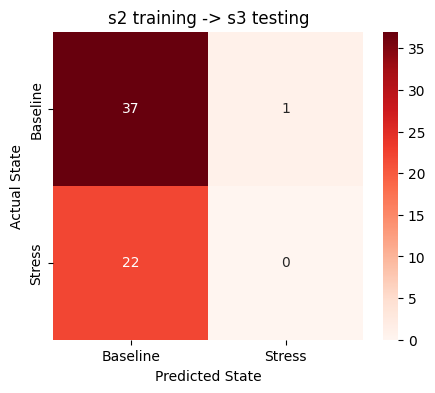

In [9]:
print("training on s2 data")
print("testing on s3 data\n")

# training on subject 2 data
x_train = df_s2.drop(columns=['label', 'subject'])
y_train = df_s2['label']

# test purely on subject 3 data (see how model performs when encountering completely new data)
x_test = df_s3.drop(columns=['label', 'subject'])
y_test = df_s3['label']

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=['Baseline', 'Stress']))

# generate and display the confusion matrix for model evaluation
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Baseline', 'Stress'],
            yticklabels=['Baseline', 'Stress'])
plt.title('s2 training -> s3 testing')
plt.ylabel('Actual State')
plt.xlabel('Predicted State')
plt.show()